# 10. Cross-currency basis and collateral-currency (CSA) discounting

## Objective

Notebooks 01-06 built a discount curve, priced linear instruments, measured
risk, and fitted a one-factor model — all in a *single currency* with a *single*
discount curve. Notebook 04 established the post-2008 principle: a
collateralised derivative is financed at the rate its collateral earns, so the
discount curve is the overnight (OIS) curve — and it noted, as a stated
limitation, that *cross-currency* collateral changes the discount curve and was
not modelled. This notebook closes that gap.

It does three things. First, it builds a **cross-currency (XCCY) basis curve**
— the spread added to one leg of a cross-currency basis swap (USD SOFR flat vs
EUR €STR plus the basis) — from a small set of illustrative tenor points.
Second, it applies **collateral-currency (CSA) discounting**: a USD-denominated
swap collateralised in EUR is discounted on the EUR curve *adjusted by the
XCCY basis*, not on the USD SOFR curve, and it shows the numerical difference in
NPV. Third, it derives the **no-arbitrage relation** that ties the basis to the
difference between the two discountings — the quanto-style adjustment of
Piterbarg (2010), "Funding beyond discounting".

## Data

The basis is the packaged dataset `illustrative_xccy_basis`: constructed, not
observed — it is not market data and not a fit to any traded price (see
`DATA_SOURCES.md`). Its closed form is `basis_bp(t) = -28.0 * (1 - exp(-t/3.0))`
on tenors from 3 months to 30 years: near zero at the short end, widening to
-28 bp at the long end — the sign and shape of the EUR/USD basis in a
USD-funding-premium regime, plausible by construction only.

The two OIS curves are taken from the frozen snapshot. The USD curve is the
repository's SOFR OIS curve (`usd_ois_curve`). The EUR curve is the snapshot's
only EUR curve, the ECB AAA government spot curve (`ecb_spot_curve`) — **not
€STR**, which the snapshot does not carry; the notebook labels it as the EUR
discounting proxy and states that caveat in Limitations.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np

from yieldcurve.curves import build
from yieldcurve.curves.pricing import par_rate
from yieldcurve.curves.xccy import (
    CsaDiscountCurve,
    basis_between,
    basis_curve_from_snapshot,
    eur_discount_curve,
    swap_npv_difference,
    usd_swap,
)
from yieldcurve.market.snapshot import Snapshot

ASOF = date(2026, 7, 24)
snapshot = Snapshot(ASOF)

basis_frame = snapshot.load("illustrative_xccy_basis").sort_values("tenor_years")
print("illustrative_xccy_basis columns:", list(basis_frame.columns))
print(basis_frame.to_string(index=False))

illustrative_xccy_basis columns: ['tenor_years', 'basis_bp']
 tenor_years  basis_bp
        0.25   -2.2388
        0.50   -4.2985
        1.00   -7.9371
        2.00  -13.6243
        3.00  -17.6994
        5.00  -22.7115
        7.00  -25.2848
       10.00  -27.0011
       15.00  -27.8113
       20.00  -27.9644
       30.00  -27.9987


In [2]:
# ## Theory
#
# **Notation.** Trade currency USD, collateral currency EUR. `S_0` is the spot FX
# (USD per EUR); `P_usd(t) = exp(-r_usd(t) t)` and `P_eur(t) = exp(-r_eur(t) t)`
# are the two OIS discount factors. The XCCY basis `b(t)` is the market's
# deviation from covered interest parity, defined through the FX forward
#
# $$ F(t) = S_0\, \frac{P_{eur}(t)}{P_{usd}(t)}\, e^{-b(t)\,t}. $$
#
# `b = 0` is pure CIP; `b < 0` (the EUR/USD sign) means the EUR forward trades
# below its CIP level — a USD funding premium.
#
# **The CSA result.** A USD cash flow of one unit at time `t`, collateralised in
# EUR, is worth `1/X_t` EUR at maturity and is funded at €STR. Its value today is
# `P_eur(t) / F(t)` EUR, or in USD `S_0 P_eur(t)/F(t)`; substituting the forward
# gives, to leading order in `b` (the Siegel's-paradox convexity of `1/X_t` is
# second order and dropped),
#
# $$ P_{usd}^{csa,eur}(t) = P_{usd}(t)\, e^{+b(t)\,t}, \qquad
#    r_{usd}^{csa,eur}(t) = r_{usd}(t) - b(t). $$
#
# This is the Piterbarg (2010) result: the discount curve is a property of the
# *collateral agreement*, not of the trade currency. **The no-arbitrage identity
# it pins is the core result** — the XCCY basis is exactly the difference between
# the two discountings,
#
# $$ b(t) = r_{usd}(t) - r_{usd}^{csa,eur}(t), $$
#
# which is why `b` is a *quanto-style* adjustment: it is what converts
# "discount in the trade currency" into "discount in the collateral currency".
#
# Two quantities are worth keeping apart. The basis `b(t)` above is a *market*
# dislocation on top of covered interest parity. The *CIP-consistent fair spread*
# of a cross-currency basis swap leg — what the basis would be if the forward
# obeyed pure OIS CIP — is instead the rate differential
# `s(t) = (P_eur - P_usd)/(t P_eur) ~ r_usd - r_eur`, implemented as
# `basis_from_zeros` in the module. The synthetic dataset carries `b(t)`, the
# dislocation, not `s(t)`.

In [3]:
# ## Method
#
# The basis curve is `BasisCurve`: linear interpolation between the synthetic
# nodes, held flat beyond the first and last (a stated extrapolation, not a
# hidden one). The CSA discount curve is `CsaDiscountCurve`, a `DiscountCurve`
# wrapping the USD OIS curve with `df(t) = df_usd(t) * exp(+b(t) t)`. The
# demonstration values one USD 3M vanilla swap two ways — once on the USD SOFR
# curve, once on the CSA-adjusted curve — leaving the *forecast* (projection)
# curve untouched, because the floating index is still USD and only the funding
# currency changes.

basis = basis_curve_from_snapshot(snapshot, ASOF)
usd = build.usd_curveset(snapshot, ASOF)
eur = eur_discount_curve(snapshot, ASOF)

print(
    f"basis at 3M/1Y/5Y/10Y/30Y (bp): "
    f"{basis.basis_bp_at(0.25):.2f} / {basis.basis_bp_at(1.0):.2f} / "
    f"{basis.basis_bp_at(5.0):.2f} / {basis.basis_bp_at(10.0):.2f} / "
    f"{basis.basis_bp_at(30.0):.2f}"
)
print(f"USD SOFR zero @ 5y: {usd.discount.zero(5.0):.5f}  ({usd.discount.zero(5.0) * 100:.3f}%)")
print(f"EUR ECB  zero @ 5y: {eur.zero(5.0):.5f}  ({eur.zero(5.0) * 100:.3f}%)")
r_csa_5y = usd.discount.zero(5.0) - basis.basis(5.0)
print(f"CSA (EUR-coll) zero @ 5y = r_usd - b = {r_csa_5y:.5f}  ({r_csa_5y * 100:.3f}%)")

basis at 3M/1Y/5Y/10Y/30Y (bp): -2.24 / -7.94 / -22.71 / -27.00 / -28.00
USD SOFR zero @ 5y: 0.04352  (4.352%)
EUR ECB  zero @ 5y: 0.02895  (2.895%)
CSA (EUR-coll) zero @ 5y = r_usd - b = 0.04579  (4.579%)


In [4]:
# The no-arbitrage identity, verified point by point: `basis_between` recovers
# the input basis as the zero-rate spread between the USD curve and the CSA curve.
csa = CsaDiscountCurve(base=usd.discount, basis=basis)
print(f"{'tenor':>6} {'r_usd':>8} {'r_csa':>8} {'basis (bp)':>10}")
for t in (0.25, 1.0, 5.0, 10.0, 30.0):
    print(
        f"{t:6.2f} {usd.discount.zero(t):8.5f} {csa.zero(t):8.5f} "
        f"{basis_between(usd.discount, csa, t) * 1e4:10.2f}"
    )

 tenor    r_usd    r_csa basis (bp)
  0.25  0.04092  0.04115      -2.24
  1.00  0.04092  0.04172      -7.94
  5.00  0.04352  0.04579     -22.71
 10.00  0.04648  0.04918     -27.00
 30.00  0.05180  0.05460     -28.00


In [5]:
# ## Results
#
# A 5-year USD 3M vanilla swap is priced at par under the USD SOFR curve (so its
# own-currency NPV is zero), then revalued on the CSA-adjusted curve. The delta
# is the pure CSA-currency effect: the swap is still *projected* off the USD
# forward curve, but *discounted* at `r_usd - b`, which is higher than `r_usd`
# because `b < 0`.

TENOR = 5.0
par_swap = usd_swap(ASOF, TENOR, 0.0)
fixed_rate = par_rate(par_swap, usd, ASOF)
swap = usd_swap(ASOF, TENOR, fixed_rate)
result = swap_npv_difference(swap, usd, basis, ASOF)

print(f"5y USD 3M swap, fixed rate (par) = {fixed_rate:.5f}  ({fixed_rate * 100:.3f}%)")
print(f"  NPV on USD SOFR (CSA in USD):  {result.base_npv:,.2f} USD")
print(f"  NPV on CSA-adjusted (CSA in EUR): {result.csa_npv:,.2f} USD")
print(
    f"  CSA-currency effect (delta):   {result.delta:+,.2f} USD "
    f"({result.delta / swap.notional * 1e4:+.2f} bp of notional)"
)

5y USD 3M swap, fixed rate (par) = 0.04395  (4.395%)
  NPV on USD SOFR (CSA in USD):  0.00 USD
  NPV on CSA-adjusted (CSA in EUR): 158.54 USD
  CSA-currency effect (delta):   +158.54 USD (+1.59 bp of notional)


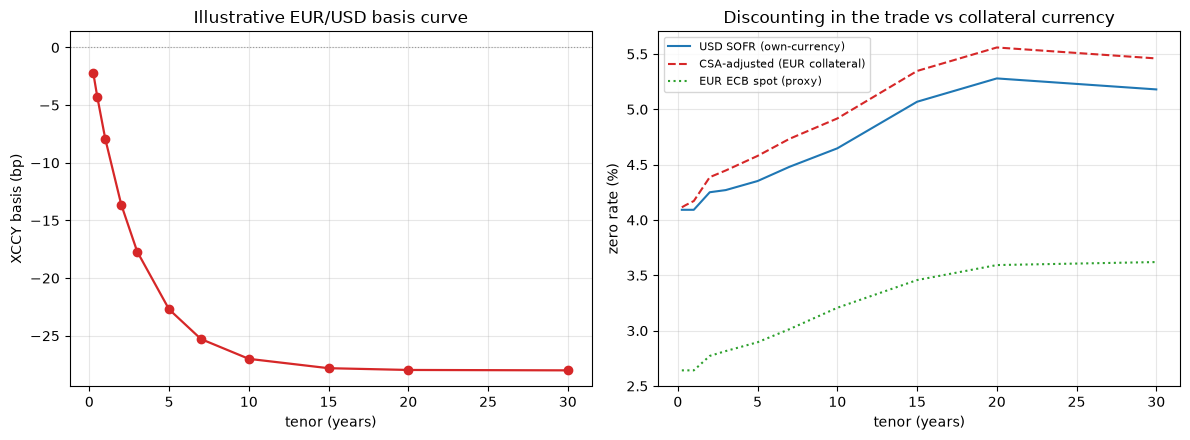

In [6]:
# The effect is small **because the swap is at par**: under a parallel discount
# shift both legs lose value, and the first-order effect cancels. What remains is
# the *timing* mismatch — the 3M floating leg is front-loaded relative to the
# annual fixed leg, so it loses less value under heavier discounting, and the
# payer (receive-floating) swap gains. The zero-rate gap that drives it, by
# contrast, is large and monotone: 23 bp at 5 years, 27 bp at 10 years.

tenors = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0])
r_usd = np.array([usd.discount.zero(t) for t in tenors])
r_csa = np.array([csa.zero(t) for t in tenors])
r_eur = np.array([eur.zero(t) for t in tenors])
basis_bp = np.array([basis.basis_bp_at(t) for t in tenors])

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_left.plot(tenors, basis_bp, "o-", color="#d62728", lw=1.6)
ax_left.axhline(0.0, color="#999999", ls=":", lw=0.8)
ax_left.set_xlabel("tenor (years)")
ax_left.set_ylabel("XCCY basis (bp)")
ax_left.set_title("Illustrative EUR/USD basis curve")
ax_left.grid(alpha=0.3)

ax_right.plot(tenors, r_usd * 100, "-", label="USD SOFR (own-currency)", color="#1f77b4")
ax_right.plot(tenors, r_csa * 100, "--", label="CSA-adjusted (EUR collateral)", color="#d62728")
ax_right.plot(tenors, r_eur * 100, ":", label="EUR ECB spot (proxy)", color="#2ca02c")
ax_right.set_xlabel("tenor (years)")
ax_right.set_ylabel("zero rate (%)")
ax_right.set_title("Discounting in the trade vs collateral currency")
ax_right.grid(alpha=0.3)
ax_right.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [7]:
# ## Limitations
#
# - **Leading order only.** The CSA discount factor drops the Siegel's-paradox
#   convexity of `1/X_t`, which is second order in the basis. For the tens of
#   basis points here it is negligible, but it is a real term at large bases or
#   long tenors.
# - **The EUR curve is a proxy.** The snapshot has no €STR OIS curve; `ecb_spot_curve`
#   is the ECB AAA *government* spot curve, which sits a small spread above €STR.
#   The EUR-anchored decomposition `r_csa = r_eur + (r_usd - r_eur) - b` is exact
#   only if `r_eur` were the true €STR rate; with the government curve it carries
#   that unmodelled government-OIS spread.
# - **Illustrative basis.** The basis dataset is constructed, not observed; the
#   NPV numbers describe the synthetic shape, not a traded mark.
# - **Single notional, no MtM resets.** The demonstration uses a fixed USD
#   notional; a mark-to-market cross-currency swap with resetting notionals has a
#   richer (but same-sign) basis sensitivity that is not modelled.
#
# ## What was and was not independently checked
#
# The closed forms are pinned against **hand-derived references** in
# `tests/curves/test_xccy.py`: the CSA discount factor `df = P_usd * exp(b t)`,
# the zero-rate identity `r_csa = r_usd - b`, the no-arbitrage recovery
# `b = r_usd - r_csa`, and a single-cash-flow NPV. There is **no QuantLib
# cross-check**, deliberately: QuantLib's cross-currency machinery applies
# covered interest parity through its FX forward, so its fair cross-currency
# basis swap spread is *zero* under pure OIS curves — it checks the CIP
# differential, not the market dislocation `b(t)` that is this notebook's input.
# The synthetic basis is an input to the calculation, not a quantity QuantLib can
# independently derive. This is software verification of an implementation, not
# empirical or regulatory model validation.
#
# ## Regulatory context
#
# Cross-currency swaps are **OTC derivatives** and in the EU fall under EMIR
# (Regulation (EU) No 648/2012): clearing, margin and reporting obligations. This
# repository makes no EMIR determination and performs no trade reporting; it only
# computes an illustrative NPV for a constructed input. The same boundary as the
# Hull-White and SABR notebooks applies: this is a pricing identity on
# illustrative data, not a validated pricing or risk model. A bank's internal
# model governance, independent validation and internal-capital assessment sit
# under CRD Articles 74, 84 and 101; none of that machinery is present here.
# Under IFRS 13, an illustrative basis is an unobservable (Level 3) input, and no
# automatic fair-value classification follows from using it; this notebook
# performs no entity-level fair-value measurement.